In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
def tetha(a, b, t, gamma_dot=1.0):
    # Paramètres physiques selon Abkarian (Section 1.3.3)
    A = -0.5  # Vorticité (négatif pour rotation horaire) [cite: 901]
    B = 0.5 * (a**2 - b**2) / (a**2 + b**2) # Forme [cite: 902]
    rp=b/a
    
    # Période de Jeffery (tau) [cite: 800]
    tau = (2 * np.pi / gamma_dot) * (rp + 1/rp)
    
    # Coefficient effectif
    coeff = np.sqrt((A + B) / (A - B))
    
    # Calcul de l'angle périodique de base (entre -pi/2 et pi/2)
    # On utilise t/tau pour la progression temporelle
    theta_base = - np.arctan(coeff * np.tan(np.pi * t / (tau/2)))
    
    # Déroulement manuel pour une courbe continue
    # floor(t / (tau/2)) compte le nombre de demi-périodes passées
    n_half_turns = np.floor(t / (tau / 2) + 0.5)
    y = theta_base - np.pi * n_half_turns
    
    return  y

class FCN(nn.Module):
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )
        self.fch = nn.Sequential(*[
                        nn.Sequential(
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
        # Initialisation spécifique des poids (Xavier/Glorot) 
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier normal est optimal pour les activations Tanh
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

19.111355309337906
torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])
tensor([[-0.0000],
        [-0.0962],
        [-0.2038],
        [-0.3395],
        [-0.5357],
        [-0.8611],
        [-1.4124],
        [-2.0491],
        [-2.4738],
        [-2.7195]])


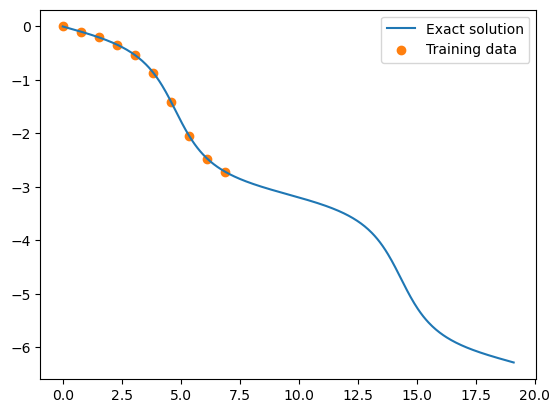

In [17]:
# condition initiale 
a ,b = 4,1.5
gamma_dot = 1.0
rp = b / a
# Période exacte de Jeffery / KS rigide
period =(2 * np.pi / gamma_dot) * (rp + 1/rp) 
print(period)

# Utilisez au moins une période complète pour l'entraînement
t = torch.linspace(0, period, 500).view(-1,1)
y = tetha(a, b, t).view(-1,1)
print(t.shape, y.shape)
# simulation 
t_data = t[0:200:20]
y_data = y[0:200:20]
print(t_data.shape, y_data.shape)
print(y_data)

plt.figure()
plt.plot(t, y, label="Exact solution")
plt.scatter(t_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

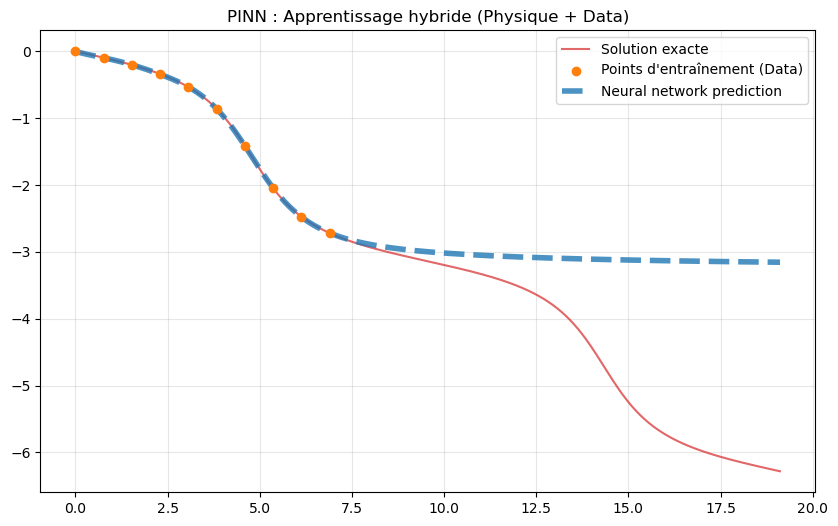

In [6]:
plt.figure(figsize=(10, 6))

# Solution exacte (Ligne bleue)
plt.plot(t_physics.detach(),tetha(a, b, t).detach(), label="Solution exacte", color="tab:red", alpha=0.7)

# Points d'entraînement (Points orange)
plt.scatter(t_data, y_data, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)

# Prédiction PINN (Ligne rouge)
yh = model(t).detach()
y_pred = model(t_physics).detach()
plt.plot(t,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction",linestyle="--")

plt.title("PINN : Apprentissage hybride (Physique + Data)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
a, b = 4.0, 1.5
gamma_dot = 1.0
A = -0.5
B = 0.5 * (a**2 - b**2) / (a**2 + b**2)
# Période théorique pour couvrir une rotation complète 
period = (2 * np.pi) / (gamma_dot * np.sqrt(0.5**2 - B**2)) 

# Temps pour la physique (Couvre la période complète)
t_physics = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
# Initialisation du modèle et de l'optimiseur
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20001):
    optimizer.zero_grad()
    
    # 1. Prédiction et Physique
    theta_pred = model(t_physics)
    dtheta_dt = torch.autograd.grad(
        theta_pred, t_physics, 
        torch.ones_like(theta_pred), 
        create_graph=True
    )[0]

    # Résidu de l'EDO
    physics_residu = dtheta_dt - gamma_dot * (A + B * torch.cos(2 * theta_pred))
    loss_physics = torch.mean(physics_residu**2)
    
    # 2. Condition Initiale
    loss_x0 = theta_pred[0]**2 
    
    # 3. Données expérimentales
    y_data_pred = model(t_data) 
    loss_data = torch.mean((y_data_pred - y_data)**2)
    
    # Pondération dynamique
    w_phys = 0.5 if epoch < 3000 else 1.0
    w_data = 100.0
    w_ci   = 500.0
    
    total_loss = w_phys * loss_physics + w_ci * loss_x0 + w_data * loss_data
    
    total_loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch}: Loss {total_loss.item():.6f} (Phys: {loss_physics.item():.4f})")

Epoch 0: Loss 113.519440 (Phys: 0.0828)
Epoch 2000: Loss 0.017900 (Phys: 0.0108)
Epoch 4000: Loss 0.006774 (Phys: 0.0062)
Epoch 6000: Loss 0.006254 (Phys: 0.0061)
Epoch 8000: Loss 0.038155 (Phys: 0.0059)
Epoch 10000: Loss 0.005964 (Phys: 0.0059)
Epoch 12000: Loss 0.006618 (Phys: 0.0059)
Epoch 14000: Loss 0.007223 (Phys: 0.0058)
Epoch 16000: Loss 0.009599 (Phys: 0.0058)
Epoch 18000: Loss 0.005745 (Phys: 0.0057)
Epoch 20000: Loss 0.005895 (Phys: 0.0057)


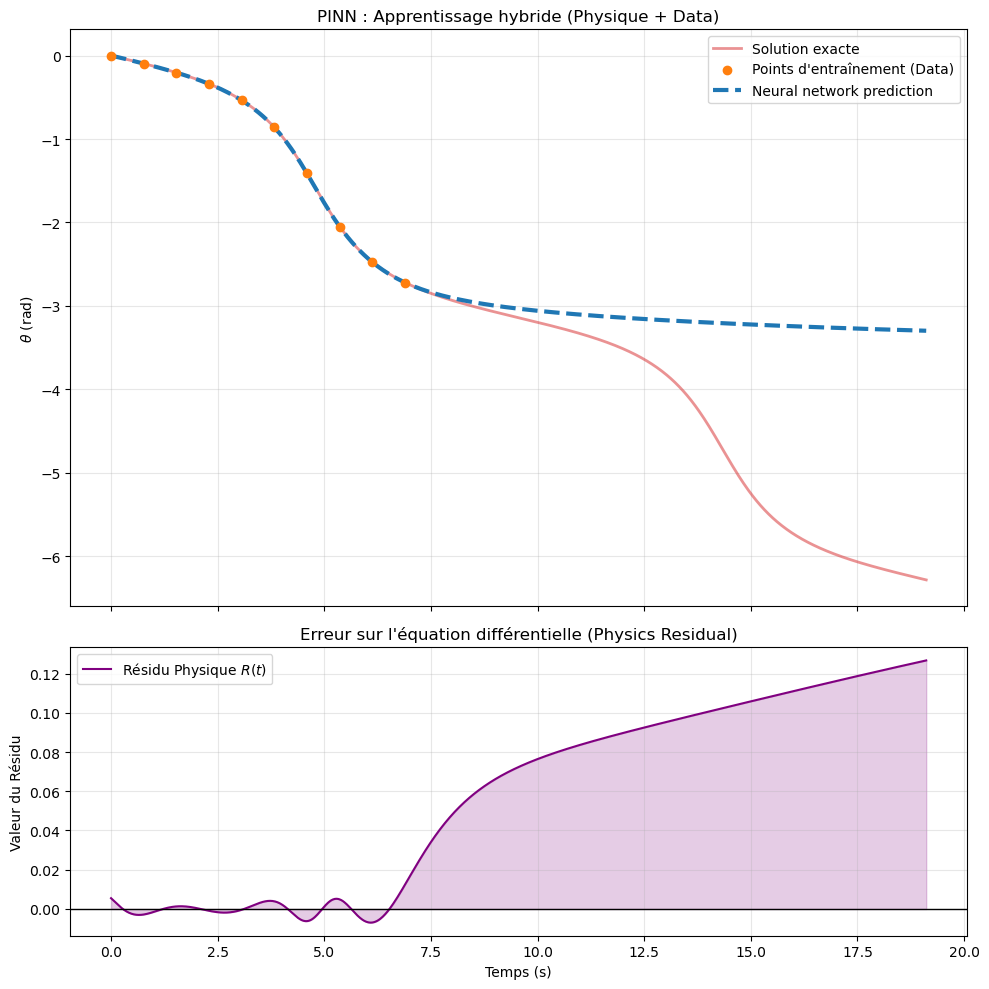

In [8]:
# 1. Préparation des données de test pour un tracé lisse
t_test = torch.linspace(0, period, 1000).view(-1, 1).requires_grad_(True)
y_pred_pinn = model(t_test)

# 2. Calcul du résidu physique ponctuel sur tout le domaine
dtheta_dt_test = torch.autograd.grad(
    y_pred_pinn, t_test, torch.ones_like(y_pred_pinn), create_graph=True
)[0]
# Calcul du résidu : R(t) = dθ/dt - [γ(A + B*cos(2θ))]
residu_final = (dtheta_dt_test - gamma_dot * (A + B * torch.cos(2 * y_pred_pinn))).detach().cpu().numpy()

# 3. Conversion sécurisée pour NumPy
t_plot = t_test.detach().cpu().numpy()
y_pinn_plot = y_pred_pinn.detach().cpu().numpy()
t_data_plot = t_data.detach().cpu().numpy()
y_data_plot = y_data.detach().cpu().numpy()

# --- Création de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- SUBPLOT 1 : Solutions ---
# Solution exacte (Conversion numpy pour éviter l'erreur dans tetha)
ax1.plot(t_plot, tetha(a, b, t_plot), label="Solution exacte", color="tab:red", alpha=0.5, lw=2)

# Points d'entraînement
ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)

# Prédiction PINN
ax1.plot(t_plot, y_pinn_plot, color="tab:blue", linewidth=3, linestyle="--", label="Neural network prediction")

ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("PINN : Apprentissage hybride (Physique + Data)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2 : Résidu Physique ---
# On affiche la valeur absolue ou brute pour voir les écarts à l'EDO
ax2.fill_between(t_plot.flatten(), residu_final.flatten(), color="purple", alpha=0.2)
ax2.plot(t_plot, residu_final, color="purple", linewidth=1.5, label="Résidu Physique $R(t)$")

ax2.axhline(0, color='black', lw=1, linestyle='-') # Ligne de référence zéro
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Valeur du Résidu")
ax2.set_title("Erreur sur l'équation différentielle (Physics Residual)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

19.111355309337906
torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])
tensor([[-0.0000],
        [-0.0962],
        [-0.2038],
        [-0.3395],
        [-0.5357],
        [-0.8611],
        [-1.4124],
        [-2.0491],
        [-2.4738],
        [-2.7195]])


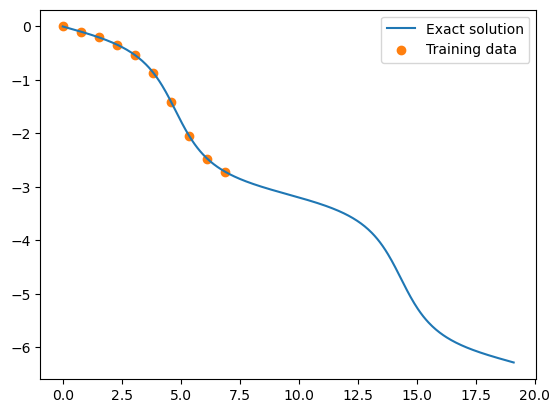

In [20]:
# condition initiale 
a ,b = 4,1.5
gamma_dot = 1.0
rp = b / a
# Période exacte de Jeffery / KS rigide
period =(2 * np.pi / gamma_dot) * (rp + 1/rp) 
print(period)

# Utilisez au moins une période complète pour l'entraînement
t = torch.linspace(0, period, 500).view(-1,1)
y = tetha(a, b, t).view(-1,1)
print(t.shape, y.shape)
# simulation 
t_data = t[0:200:20]
y_data = y[0:200:20]
print(t_data.shape, y_data.shape)
print(y_data)

plt.figure()
plt.plot(t, y, label="Exact solution")
plt.scatter(t_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuration de l'optimiseur L-BFGS
optimizer = torch.optim.LBFGS(
    model.parameters(), 
    lr=1, 
    max_iter=20, 
    history_size=10, 
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer.zero_grad()
    
    # 1. Résidu Physique
    theta_pred_phys = model(t_physics)
    dtheta_dt = torch.autograd.grad(
        theta_pred_phys, t_physics, 
        torch.ones_like(theta_pred_phys), 
        create_graph=True
    )[0]
    
    # Équation : dθ/dt - γ * (A + B * cos(2θ)) = 0
    residu = dtheta_dt - gamma_dot * (A + B * torch.cos(2 * theta_pred_phys))
    loss_phys = torch.mean(residu**2)
    
    # 2. Condition Initiale (t=0, theta=0)
    t0 = torch.tensor([[0.0]], requires_grad=True)
    loss_ci = model(t0)**2
    
    # 3. Perte sur les données (Data)
    loss_data = torch.mean((model(t_data) - y_data)**2)
    
    # Somme pondérée
    total_loss = 60.0 * loss_phys + 500.0 * loss_ci + 100.0 * loss_data
    
    total_loss.backward()
    return total_loss

# Boucle d'optimisation
epochs = 500
for i in range(epochs):
    loss = optimizer.step(closure)
    if i % 50 == 0:
        print(f"Étape {i}: Loss totale = {loss.item():.6f}")

Étape 0: Loss totale = 0.204049
Étape 50: Loss totale = 0.204049
Étape 100: Loss totale = 0.204049
Étape 150: Loss totale = 0.204049
Étape 200: Loss totale = 0.204049
Étape 250: Loss totale = 0.204049
Étape 300: Loss totale = 0.204049
Étape 350: Loss totale = 0.204049
Étape 400: Loss totale = 0.204049
Étape 450: Loss totale = 0.204049


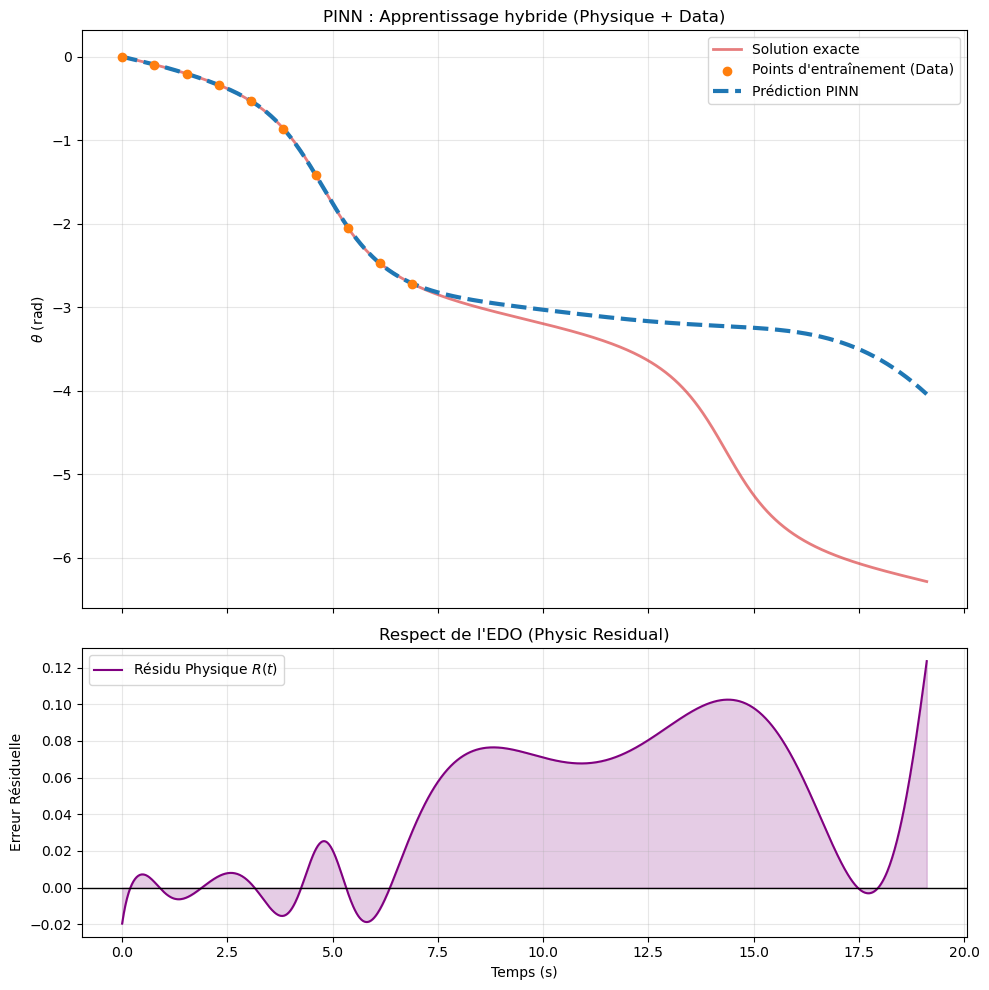

In [19]:
# 1. Génération des données de test
t_test = torch.linspace(0, period, 1000).view(-1, 1).requires_grad_(True)
y_pred_pinn = model(t_test)

# 2. Calcul du résidu physique final pour le plot
dtheta_dt_final = torch.autograd.grad(
    y_pred_pinn, t_test, torch.ones_like(y_pred_pinn), create_graph=True
)[0]
# On calcule le résidu ponctuel
res_final = (dtheta_dt_final - gamma_dot * (A + B * torch.cos(2 * y_pred_pinn))).detach().cpu().numpy()

# 3. Conversion pour NumPy (Sécurité pour matplotlib et fonction exacte)
t_plot = t_test.detach().cpu().numpy()
y_plot = y_pred_pinn.detach().cpu().numpy()
t_data_plot = t_data.detach().cpu().numpy()
y_data_plot = y_data.detach().cpu().numpy()

# --- Création du Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# Subplot 1 : Comparaison
# On passe t_plot (numpy) à la fonction tetha
ax1.plot(t_plot, tetha(a, b, t_plot), label="Solution exacte", color="tab:red", alpha=0.6, lw=2)
ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)
ax1.plot(t_plot, y_plot, color="tab:blue", linewidth=3, linestyle="--", label="Prédiction PINN")

ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("PINN : Apprentissage hybride (Physique + Data)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2 : Résidu Physique
ax2.fill_between(t_plot.flatten(), res_final.flatten(), color="purple", alpha=0.2)
ax2.plot(t_plot, res_final, color="purple", linewidth=1.5, label="Résidu Physique $R(t)$")

ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Erreur Résiduelle")
ax2.axhline(0, color='black', lw=1) # Ligne de zéro
ax2.set_title("Respect de l'EDO (Physic Residual)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()